1. Initializing system...
Device in use: cpu
2. Loading AI Brain...
Loading weights from: c:\Users\MangOS\plant-disease-ai\models\resnet18_phase2_best.pth
3. Running Diagnostic and Grad-CAM...
Selected Image: C:\Users\MangOS\plant-disease-ai\data\PlantVillage\Tomato___Bacterial_spot\0c32d6d5-bf5b-4904-8108-d7a901f2cb6b___UF.GRC_BS_Lab Leaf 8662.JPG
Analyzing image: C:\Users\MangOS\plant-disease-ai\data\PlantVillage\Tomato___Bacterial_spot\0c32d6d5-bf5b-4904-8108-d7a901f2cb6b___UF.GRC_BS_Lab Leaf 8662.JPG
AI Prediction: Tomato: Bacterial Spot (100.00%)


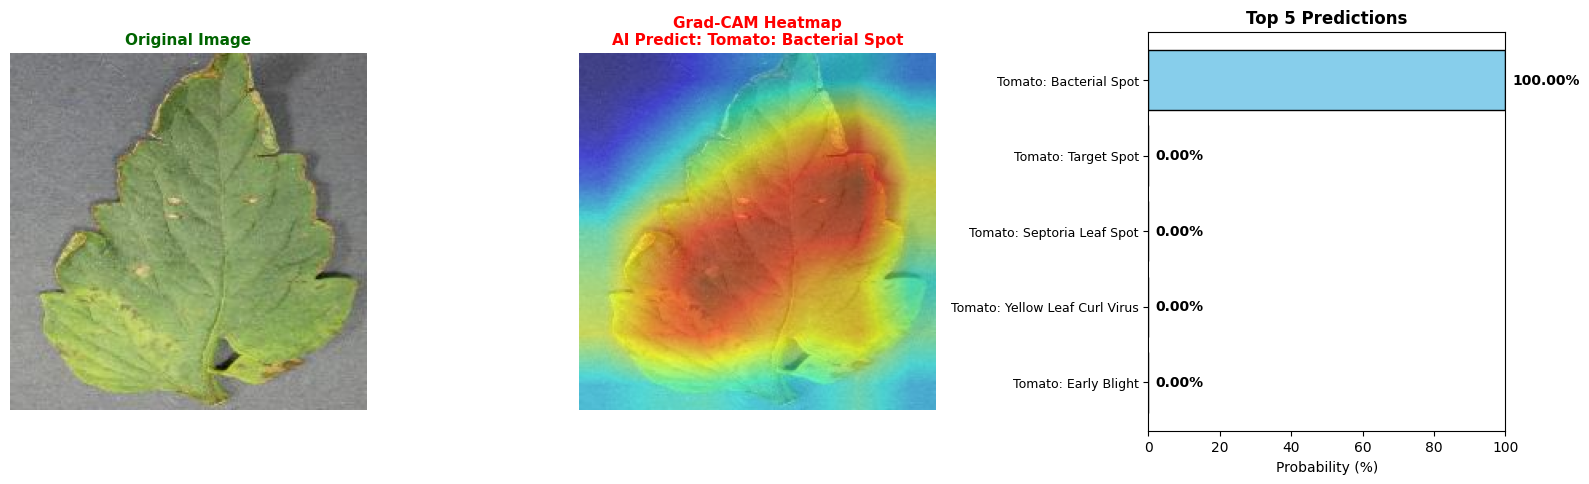


           DISEASE INFORMATION

Tên bệnh: Bệnh đốm vi khuẩn
Tên tiếng Anh: Bacterial Spot
Cây trồng: Cà chua

Mô tả:
Bệnh đốm vi khuẩn là một trong những bệnh tàn phá nghiêm trọng nhất trên cây cà chua. Bệnh gây tổn hại nghiêm trọng đến tán lá, làm rụng lá sớm và khiến quả xuất hiện các vết đốm sần sùi, mất giá trị thương phẩm.

Triệu chứng:
- Trên lá xuất hiện các đốm nhỏ sũng nước, sau chuyển sang màu đen hoặc nâu.
- Xung quanh các vết đốm trên lá thường có một quầng màu vàng, lá bị bệnh nặng sẽ héo và rụng.
- Trên thân cây cũng xuất hiện các vết đốm hình bầu dục dài màu nâu sẫm.
- Quả cà chua xuất hiện các vết đốm sần sùi, gồ ghề, màu đen hoặc xám, có thể đóng vảy lõm xuống.

Nguyên nhân:
- Gây ra bởi vi khuẩn Xanthomonas campestris pv. vesicatoria (hoặc các loài Xanthomonas khác).
- Vi khuẩn lây lan qua hạt giống bị nhiễm bệnh, cây giống, tàn dư cây trồng, hoặc cỏ dại.
- Lây lan nhanh qua gió kèm mưa, nước tưới phun mưa, hoặc do người và dụng cụ chạm vào cây khi ướt.
- Xâm nhập và

In [2]:
import sys
import os
import torch

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(PROJECT_ROOT)

from src.load_model import load_best_model
from src.gradcam import visualize_gradcam
from src.disease_database import get_disease


CUSTOM_IMAGE_PATH = r"C:\Users\MangOS\plant-disease-ai\data\PlantVillage\Tomato___Bacterial_spot\0c32d6d5-bf5b-4904-8108-d7a901f2cb6b___UF.GRC_BS_Lab Leaf 8662.JPG"
# ==========================================

print("1. Initializing system...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

print("2. Loading AI Brain...")
model = load_best_model(device)

print(f"3. Running Diagnostic and Grad-CAM...")
print(f"Selected Image: {CUSTOM_IMAGE_PATH}")

predicted_class = visualize_gradcam(
    model,
    CUSTOM_IMAGE_PATH,
    true_label=None
)

disease = get_disease(predicted_class)

if disease is None:

    print("\nKhông tìm thấy thông tin trong diseases.json")

    print(
        f"Class cần tìm: {predicted_class}"
    )

else:

    print("\n========================================")
    print("           DISEASE INFORMATION")
    print("========================================")

    print(f"\nTên bệnh: {disease['name']}")

    print(
        f"Tên tiếng Anh: "
        f"{disease['english_name']}"
    )

    print(
        f"Cây trồng: "
        f"{disease['crop']}"
    )

    print("\nMô tả:")
    print(disease['description'])

    print("\nTriệu chứng:")

    for symptom in disease['symptoms']:
        print(f"- {symptom}")

    print("\nNguyên nhân:")

    for cause in disease['cause']:
        print(f"- {cause}")

    print("\nPhòng ngừa:")

    for item in disease['prevention']:
        print(f"- {item}")

    print("\nCách điều trị:")

    for item in disease['treatment']:
        print(f"- {item}")

print("Custom Demo completed successfully!")